In [67]:
import pandas as pd

ames_housing = pd.read_csv("../datasets/ames_housing_no_missing.csv")
target_name = "SalePrice"
data = ames_housing.drop(columns=target_name)
target = ames_housing[target_name]

numerical_features = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
]

data_numerical = data[numerical_features]

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

model = make_pipeline(StandardScaler(), Ridge(alpha=0))

cv_results = cross_validate(
    model, 
    data_numerical, 
    target, 
    cv=10, 
    scoring="neg_mean_absolute_error", 
    n_jobs=2, 
    return_estimator=True
)
cv_results["test_error"] = -cv_results["test_score"]

In [69]:
coefs = [pipeline[-1].coef_ for pipeline in cv_results["estimator"]]
coefs = pd.DataFrame(coefs, columns=data_numerical.columns)
coefs.abs().max().max()

np.float64(1.870614909293722e+19)

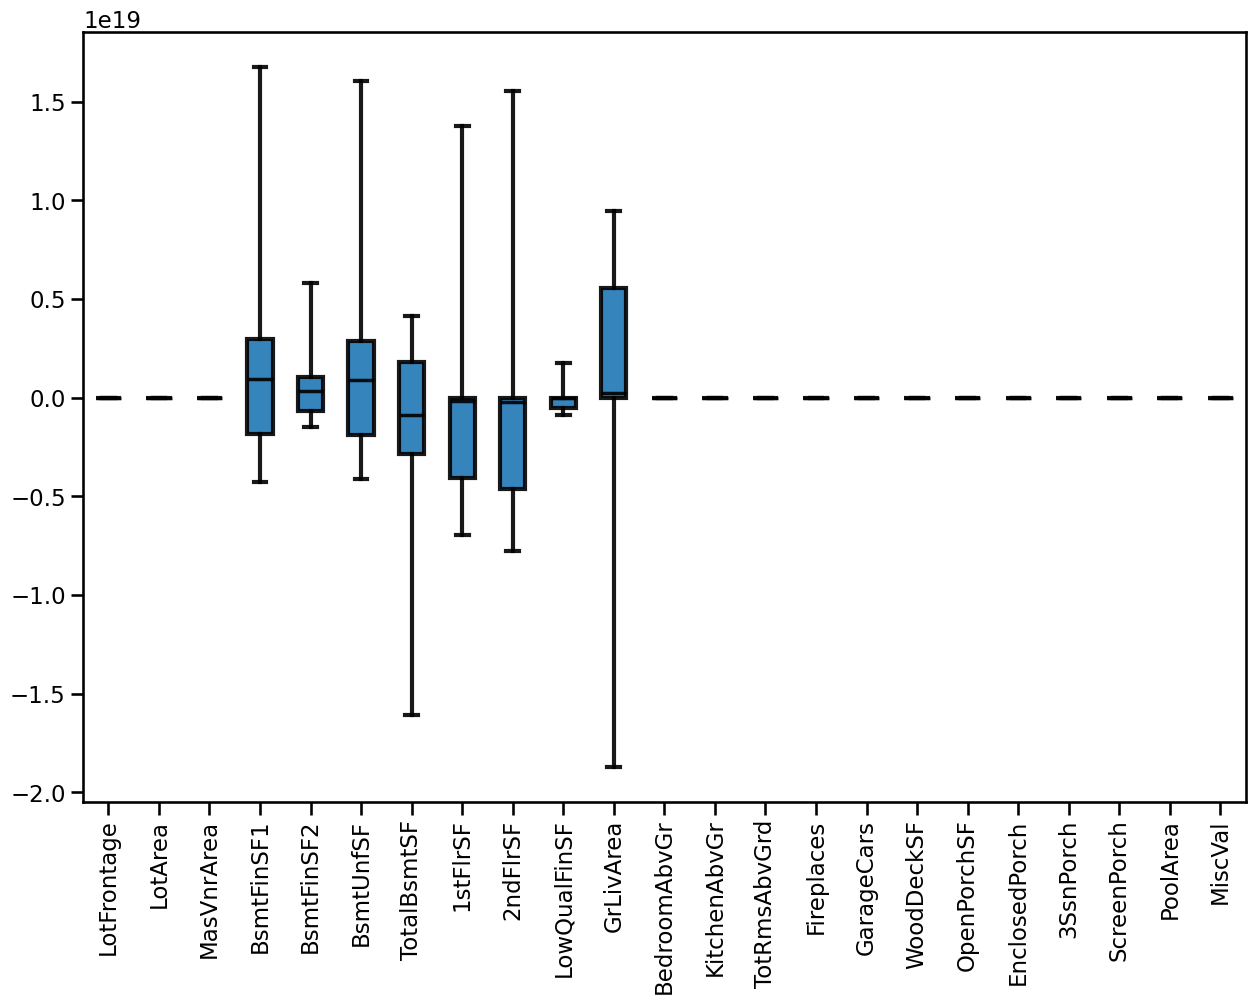

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
# Define the style of the box style
boxplot_property = {
    "vert": True,
    "whis": 100,
    "patch_artist": True,
    "widths": 0.5,
    "rot": 90,
    "boxprops": dict(linewidth=3, color="black", alpha=0.9),
    "medianprops": dict(linewidth=2.5, color="black", alpha=0.9),
    "whiskerprops": dict(linewidth=3, color="black", alpha=0.9),
    "capprops": dict(linewidth=3, color="black", alpha=0.9),
}

_, ax = plt.subplots(figsize=(15, 10))
_ = coefs.plot.box(**boxplot_property, ax=ax)

In [71]:
model.get_params()

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('ridge', Ridge(alpha=0))],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'ridge': Ridge(alpha=0),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'ridge__alpha': 0,
 'ridge__copy_X': True,
 'ridge__fit_intercept': True,
 'ridge__max_iter': None,
 'ridge__positive': False,
 'ridge__random_state': None,
 'ridge__solver': 'auto',
 'ridge__tol': 0.0001}

coefs_1.abs().max().max() = 19963.351137556878


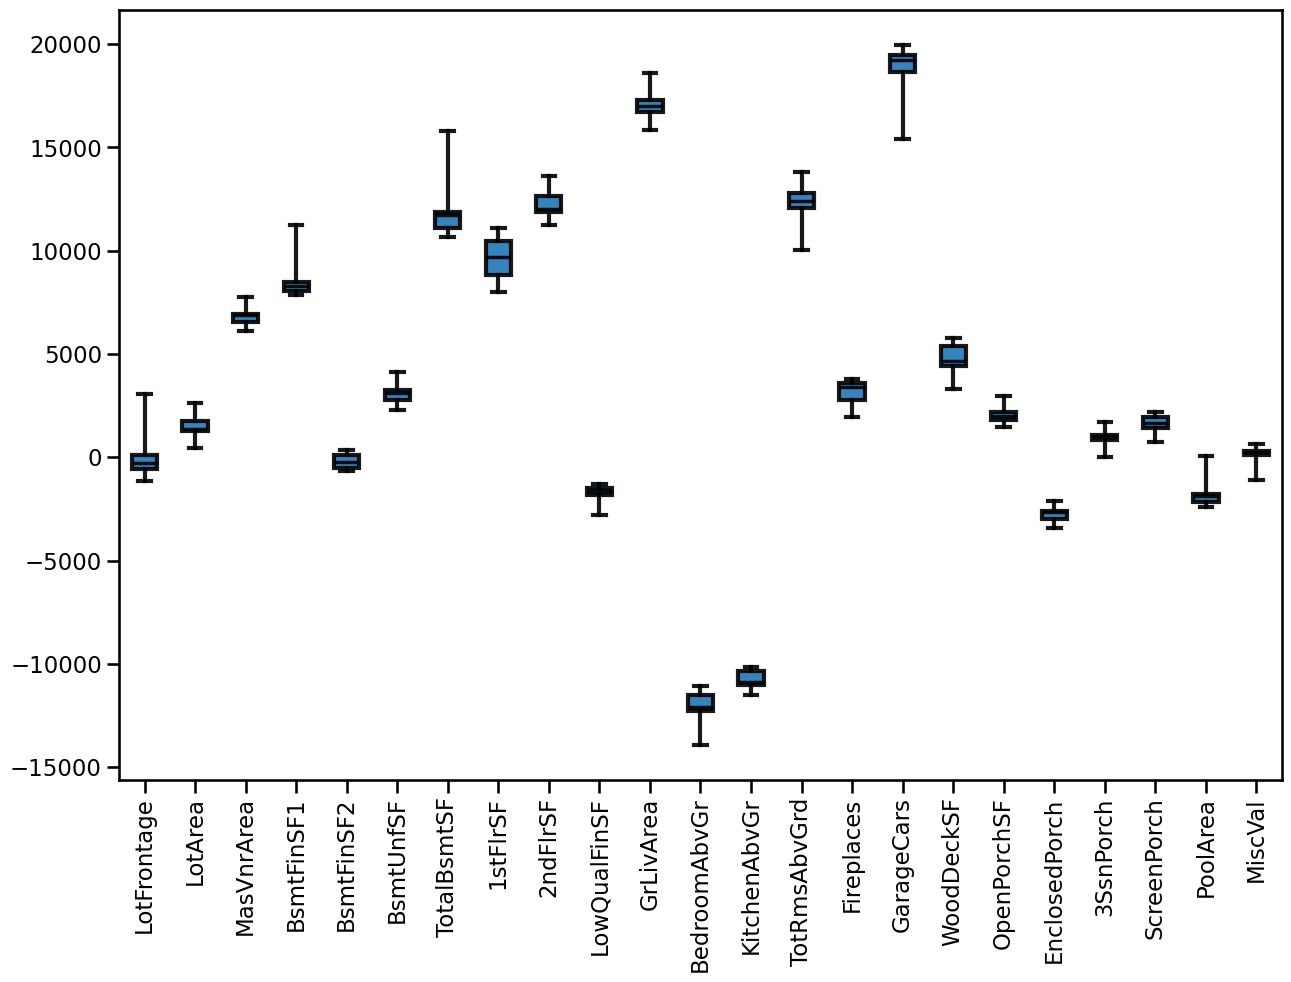

In [72]:
model.set_params(ridge__alpha=1.0)

cv_results_1 = cross_validate(
    model, 
    data_numerical, 
    target, 
    cv=10, 
    scoring="neg_mean_absolute_error", 
    n_jobs=2, 
    return_estimator=True
)
cv_results_1["test_error"] = -cv_results_1["test_score"]

coefs_1 = [pipeline[-1].coef_ for pipeline in cv_results_1["estimator"]]
coefs_1 = pd.DataFrame(coefs_1, columns=data_numerical.columns)
print(f"coefs_1.abs().max().max() = {coefs_1.abs().max().max()}")

_, ax = plt.subplots(figsize=(15, 10))
_ = coefs_1.plot.box(**boxplot_property, ax=ax)

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
import numpy as np

alphas = np.logspace(-3, 3, 101)
model = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas))

cv_results_num_only  = cross_validate(
    model, 
    data_numerical, 
    target, 
    cv=10, 
    n_jobs=2, 
    return_estimator=True
)

test_score_num_only = cv_results_num_only["test_score"]

coefs = [pipeline[-1].coef_ for pipeline in cv_results_num_only["estimator"]]
coefs = pd.DataFrame(coefs, columns=data_numerical.columns)
coefs["GarageCars"].std()

np.float64(587.5476658335926)

In [74]:
tuned_alphas = [pipeline[-1].alpha_ for pipeline in cv_results_num_only["estimator"]]
tuned_alphas

[331.13112148259074,
 331.13112148259074,
 288.40315031266056,
 331.13112148259074,
 331.13112148259074,
 331.13112148259074,
 288.40315031266056,
 331.13112148259074,
 63.0957344480193,
 331.13112148259074]

A model using both numerical and categorical features is better than a model using only numerical features for 10 CV iterations out of 10.


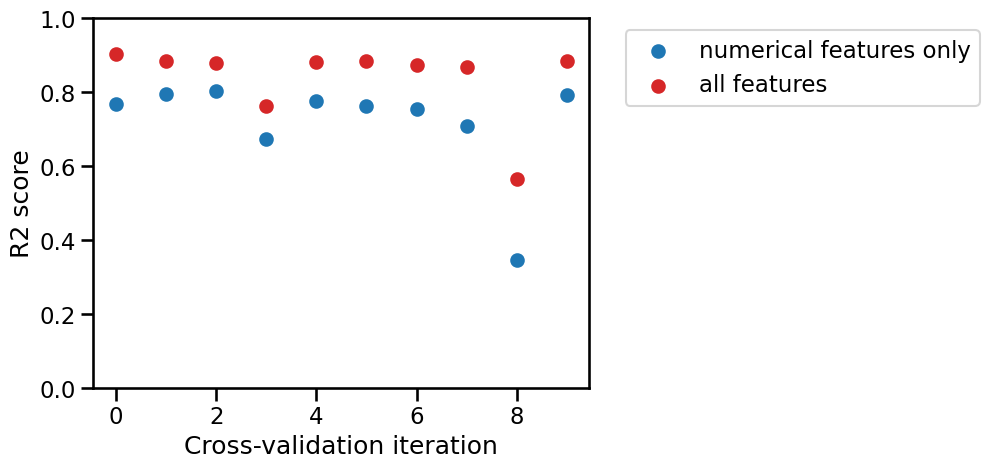

In [75]:
from sklearn.compose import make_column_selector as selector
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = selector(dtype_include=object)(data)

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (StandardScaler(), numerical_features),
)
model = make_pipeline(preprocessor, RidgeCV(alphas=alphas))
cv_results_num_and_cat = cross_validate(
    model, data, target, cv=10, n_jobs=2
)
test_score_num_and_cat = cv_results_num_and_cat["test_score"]

indices = np.arange(len(test_score_num_only))
plt.scatter(
    indices,
    test_score_num_only,
    color="tab:blue",
    label="numerical features only"
)
plt.scatter(
    indices,
    test_score_num_and_cat,
    color="tab:red",
    label="all features",
)
plt.ylim((0, 1))
plt.xlabel("Cross-validation iteration")
plt.ylabel("R2 score")
_ = plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

print(
    "A model using both numerical and categorical features is better than a"
    " model using only numerical features for"
    f" {sum(test_score_num_and_cat > test_score_num_only)} CV iterations out of 10."
)

A model using all features with non-linear feature engineering is better  than the previous pipeline for 8 CV iterations out of 10.


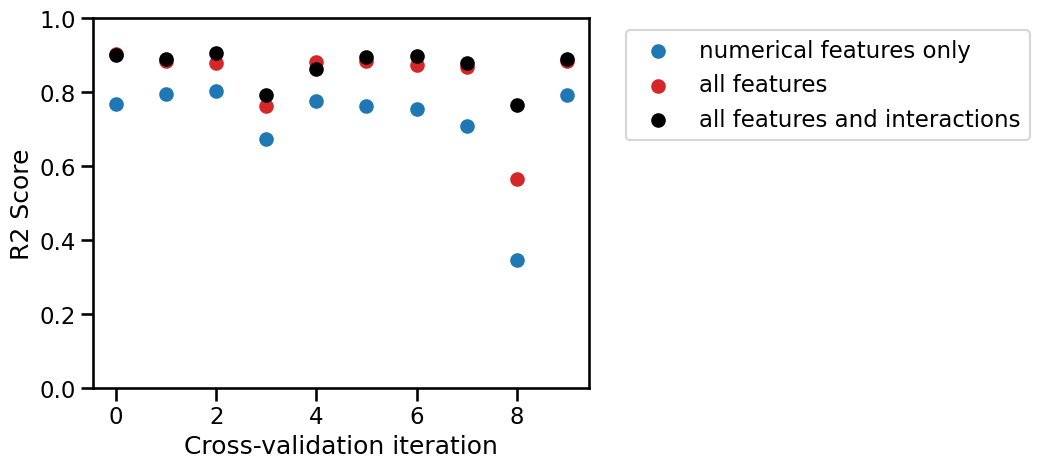

In [79]:
from sklearn.kernel_approximation import Nystroem
from sklearn.preprocessing import SplineTransformer


preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
    (SplineTransformer(), numerical_features),
)

model_with_interaction = make_pipeline(
    preprocessor,
    Nystroem(kernel="poly", degree=2, n_components=300),
    RidgeCV(alphas=alphas)
)
cv_results_interactions = cross_validate(
    model_with_interaction,
    data,
    target,
    cv=10,
    n_jobs=2,
)
test_score_interactions = cv_results_interactions["test_score"]

plt.scatter(
    indices,
    test_score_num_only,
    color="tab:blue",
    label="numerical features only"
)
plt.scatter(
    indices,
    test_score_num_and_cat,
    color="tab:red",
    label="all features",
)
plt.scatter(
    indices,
    test_score_interactions,
    color="black",
    label="all features and interactions",
)
plt.ylim((0, 1))
plt.xlabel("Cross-validation iteration")
plt.ylabel("R2 Score")
_ = plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

print(
    "A model using all features with non-linear feature engineering is better"
    "  than the previous pipeline for"
    f" {sum(test_score_interactions > test_score_num_and_cat)} CV iterations"
    " out of 10."
)